<a href="https://colab.research.google.com/github/abdulbasitbhat/CUDA/blob/main/CUDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Thu Aug 27 14:22:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!nvcc --version


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [4]:
%%writefile hello.cu

#include <stdio.h>

__global__ void hello() {
    printf("Hello from GPU! Block %d, Thread %d\n",
           blockIdx.x, threadIdx.x);
}

int main() {
    hello<<<2, 4>>>();
    cudaDeviceSynchronize();

    return 0;
}

Overwriting hello.cu


In [6]:
!nvcc hello.cu -o hello

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [7]:
!./hello

Hello from GPU! Block 1, Thread 0
Hello from GPU! Block 1, Thread 1
Hello from GPU! Block 1, Thread 2
Hello from GPU! Block 1, Thread 3
Hello from GPU! Block 0, Thread 0
Hello from GPU! Block 0, Thread 1
Hello from GPU! Block 0, Thread 2
Hello from GPU! Block 0, Thread 3


In [8]:
!pip install nvcc4jupyter

In [9]:
%load_ext nvcc4jupyter

Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpct23g9d0".


In [11]:
%%cuda

#include <stdio.h>

__global__ void hello() {
    printf("Hello from GPU! Block %d, Thread %d\n",
           blockIdx.x, threadIdx.x);
}

int main() {
    hello<<<2, 4>>>();
    cudaDeviceSynchronize();

    return 0;
}

Hello from GPU! Block 0, Thread 0
Hello from GPU! Block 0, Thread 1
Hello from GPU! Block 0, Thread 2
Hello from GPU! Block 0, Thread 3
Hello from GPU! Block 1, Thread 0
Hello from GPU! Block 1, Thread 1
Hello from GPU! Block 1, Thread 2
Hello from GPU! Block 1, Thread 3



This is a CPU program that launches work on the GPU.

__ global__ tells CUDA: This function runs on the GPU and is called from the CPU. Such a function is called a kernel.

hello<<<2, 4>>>(); is a GPU kernel launch.

<<< number_of_blocks, threads_per_block >>>

Grid  
Block 0  
*   Thread 0
*   Thread 1
*   Thread 2
*   Thread 3   

Block 1  
*   Thread 0
*   Thread 1
*   Thread 2
*   Thread 3  

Block 0 → blockIdx.x = 0  
Block 1 → blockIdx.x = 1  

Thread 0 → threadIdx.x = 0  
Thread 1 → threadIdx.x = 1  
Thread 2 → threadIdx.x = 2  
Thread 3 → threadIdx.x = 3  


cudaDeviceSynchronize();  
CPU launches:hello<<<2, 4>>>();  
The launch is generally asynchronous from the CPU's perspective.
It makes CPU wait until the GPU has finished its work.



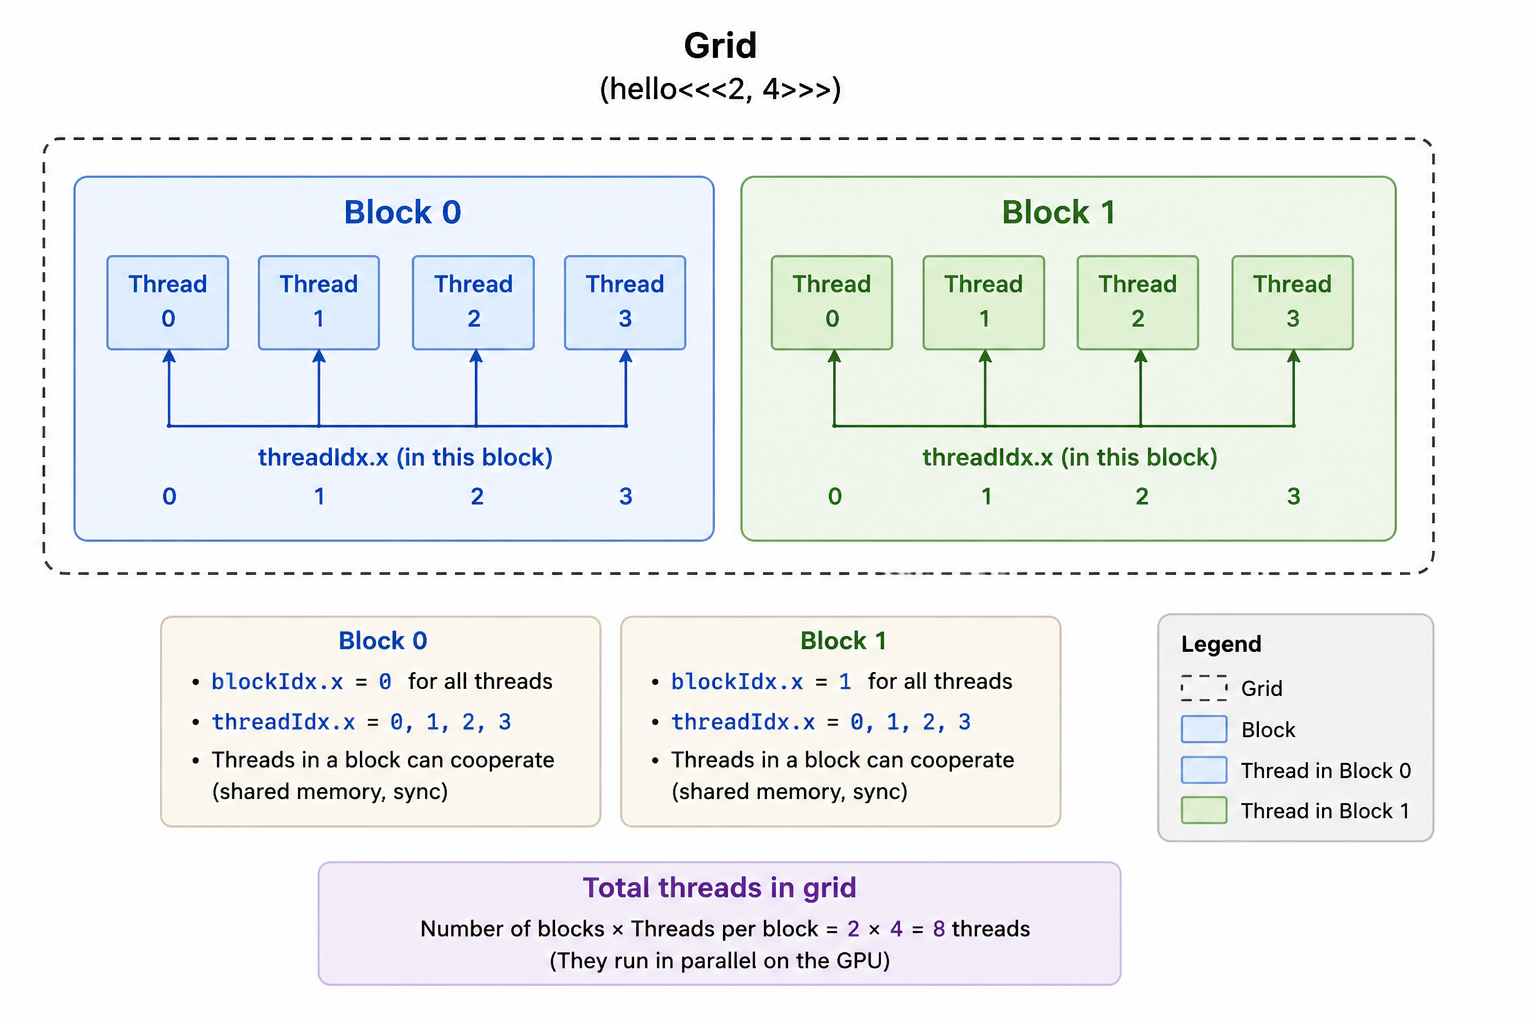

In [17]:
#Vector Addition

%%cuda
#include <stdio.h>
#include <cuda_runtime.h>

//Kernel
/*
Block 0
  blockIdx.x = 0
  blockDim.x = 4
  Thread 0 → i = 0 × 4 + 0 = 0
  Thread 1 → i = 0 × 4 + 1 = 1
  Thread 2 → i = 0 × 4 + 2 = 2
  Thread 3 → i = 0 × 4 + 3 = 3

Block 1
  blockIdx.x = 1
  blockDim.x = 4
  Thread 0 → i = 1 × 4 + 0 = 4
  Thread 1 → i = 1 × 4 + 1 = 5
  Thread 2 → i = 1 × 4 + 2 = 6
  Thread 3 → i = 1 × 4 + 3 = 7

2 block, each 4 threads = 8 threads
Each thread processing an elment parallely

*/
__global__ void vectorAdd(int *a, int *b, int *c)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    c[i] = a[i] + b[i];
}

int main()
{
    const int N = 8;

    int a[N] = {1,2,3,4,5,6,7,8};
    int b[N] = {10,20,30,40,50,60,70,80};
    int c[N];

    // Allocate memory on GPU
    int *d_a,*d_b,*d_c;

    cudaMalloc(&d_a, N*sizeof(int));
    cudaMalloc(&d_b, N*sizeof(int));
    cudaMalloc(&d_c, N*sizeof(int));

    //Copy data CPU to GPU
    cudaMemcpy(d_a,a,N*sizeof(int),cudaMemcpyHostToDevice);
    cudaMemcpy(d_b,b,N*sizeof(int),cudaMemcpyHostToDevice);

    //Launch GPU Kernel
    vectorAdd<<<2,4>>>(d_a,d_b,d_c);

    //CPU awaits
    cudaDeviceSynchronize();

    //Copy data GPU to CPU
    cudaMemcpy(c,d_c,N*sizeof(int),cudaMemcpyDeviceToHost);

    for(int i=0;i<N;i++)
    {
        printf("%d + %d = %d\n", a[i], b[i], c[i]);
    }

    //Free
    cudaFree(d_a);
    cudaFree(d_b);
    cudaFree(d_c);

    return 0;

}

1 + 10 = 11
2 + 20 = 22
3 + 30 = 33
4 + 40 = 44
5 + 50 = 55
6 + 60 = 66
7 + 70 = 77
8 + 80 = 88



In [26]:
%%cuda

#include <stdio.h>
#include <cuda_runtime.h>

#define N 3

__global__ void matrixMul(int *A, int *B, int *C)
{
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < N && col < N)
    {
        int sum = 0;

        for (int k = 0; k < N; k++)
        {
            sum += A[row * N + k] * B[k * N + col];
        }

        C[row * N + col] = sum;
    }
}

int main()
{
    int A[N][N] =
    {
        {1, 2, 3},
        {4, 5, 6},
        {7, 8, 9}
    };

    int B[N][N] =
    {
        {9, 8, 7},
        {6, 5, 4},
        {3, 2, 1}
    };

    int C[N][N];

    int *d_A, *d_B, *d_C;

    cudaMalloc(&d_A, N * N * sizeof(int));
    cudaMalloc(&d_B, N * N * sizeof(int));
    cudaMalloc(&d_C, N * N * sizeof(int));

    cudaMemcpy(
        d_A,
        A,
        N * N * sizeof(int),
        cudaMemcpyHostToDevice
    );

    cudaMemcpy(
        d_B,
        B,
        N * N * sizeof(int),
        cudaMemcpyHostToDevice
    );

    // One block containing 3 x 3 = 9 threads per block
    dim3 threadsPerBlock(3, 3);

    // 3 x 3 matrix / 3 x 3 threads = 1 x 1 block each having 9 threads
    dim3 numberOfBlocks(
        (N + threadsPerBlock.x - 1) / threadsPerBlock.x,
        (N + threadsPerBlock.y - 1) / threadsPerBlock.y
    );

    matrixMul<<<numberOfBlocks, threadsPerBlock>>>(
        d_A,
        d_B,
        d_C
    );

    cudaDeviceSynchronize();

    cudaMemcpy(
        C,
        d_C,
        N * N * sizeof(int),
        cudaMemcpyDeviceToHost
    );

    printf("Matrix A:\n");

    for (int i = 0; i < N; i++)
    {
        for (int j = 0; j < N; j++)
        {
            printf("%4d ", A[i][j]);
        }

        printf("\n");
    }

    printf("\nMatrix B:\n");

    for (int i = 0; i < N; i++)
    {
        for (int j = 0; j < N; j++)
        {
            printf("%4d ", B[i][j]);
        }

        printf("\n");
    }

    printf("\nMatrix C = A x B:\n");

    for (int i = 0; i < N; i++)
    {
        for (int j = 0; j < N; j++)
        {
            printf("%4d ", C[i][j]);
        }

        printf("\n");
    }

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}


/*
__global__ void matrixMul(int *A, int *B, int *C)
{
    // Which row and column does this thread handle?
    //blockIdx.y = 0
    //blockDim.y = 3
    //row = 0 × 3 + threadIdx.y
    //Thread (0,0) → row = 0
    //Thread (1,0) → row = 0
    //Thread (2,0) → row = 0

    //Thread (0,1) → row = 1
    //Thread (1,1) → row = 1
    //Thread (2,1) → row = 1

    //Thread (0,2) → row = 2
    //Thread (1,2) → row = 2
    //Thread (2,2) → row = 2

    //threadIdx.y determines the row.

    //col = 0 × 3 + threadIdx.x
    //Thread (0,0) → col = 0
    //Thread (1,0) → col = 1
    //Thread (2,0) → col = 2

    //Thread (0,1) → col = 0
    //Thread (1,1) → col = 1
    //Thread (2,1) → col = 2

    //Thread (0,2) → col = 0
    //Thread (1,2) → col = 1
    //Thread (2,2) → col = 2

    //threadIdx.x determines the column.

                        col
                0     1     2
            ┌─────┬─────┬─────┐
      row 0  │ T   │ T   │ T   │
            │     │     │     │
            ├─────┼─────┼─────┤
      row 1  │ T   │ T   │ T   │
            │     │     │     │
            ├─────┼─────┼─────┤
      row 2  │ T   │ T   │ T   │
            │     │     │     │
            └─────┴─────┴─────┘

              ↓

                    C

                0     1     2
            ┌─────┬─────┬─────┐
          0  │ C00 │ C01 │ C02 │
            ├─────┼─────┼─────┤
          1  │ C10 │ C11 │ C12 │
            ├─────┼─────┼─────┤
          2  │ C20 │ C21 │ C22 │
            └─────┴─────┴─────┘


    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    // Make sure thread is inside the matrix
    if (row < N && col < N)
    {
        int sum = 0;

        // Calculate C[row][col]
        for (int k = 0; k < N; k++)
        {
            sum += A[row * N + k] * B[k * N + col];
        }

        C[row * N + col] = sum;

            row = 0
            col = 0
            N = 3

            k = 0
            A[0 × 3 + 0] × B[0 × 3 + 0] = A[0] × B[0]
            corresponds to A[0][0] × B[0][0]
            A =

                    col
                    0   1   2
                  ┌───┬───┬───┐
            row 0 │ 1 │ 2 │ 3 │
                  ├───┼───┼───┤
            row 1 │ 4 │ 5 │ 6 │
                  ├───┼───┼───┤
            row 2 │ 7 │ 8 │ 9 │
                  └───┴───┴───┘
                    Memory:

            Index:    0    1    2    3    4    5    6    7    8
                      │    │    │    │    │    │    │    │    │
                      ▼    ▼    ▼    ▼    ▼    ▼    ▼    ▼    ▼
            A:       [1]  [2]  [3]  [4]  [5]  [6]  [7]  [8]  [9]

            Row 0       Row 1       Row 2
            ───────     ───────     ───────
            1D index = row × 3 + column
            A[0][0] → memory index 0
            A[0][1] → memory index 1
            A[0][2] → memory index 2

            A[1][0] → memory index 3
            A[1][1] → memory index 4
            A[1][2] → memory index 5

            A[2][0] → memory index 6
            A[2][1] → memory index 7
            A[2][2] → memory index 8

            k = 1
            A[0 × 3 + 1] × B[1 × 3 + 0] = A[0][1] × B[1][0]

            k = 2
            A[0 × 3 + 2] × B[2 × 3 + 0] = A[0][2] × B[2][0]

            C[0][0]
              = A[0][0] × B[0][0]
              + A[0][1] × B[1][0]
              + A[0][2] × B[2][0]
    }
}
*/

Matrix A:
   1    2    3 
   4    5    6 
   7    8    9 

Matrix B:
   9    8    7 
   6    5    4 
   3    2    1 

Matrix C = A x B:
  30   24   18 
  84   69   54 
 138  114   90 

